# 3. POS Tagging
Aplica POS tagging con NLTK y spaCy al corpus limpio y compara resultados.
Toda la lógica vive en `src/pos_tagging.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import pandas as pd

from pos_tagging import setup_nltk, cargar_spacy, pos_tagging_nltk, pos_tagging_spacy, comparar_nltk_spacy, graficar_distribucion_pos


In [ ]:
# Preparar dependencias 
setup_nltk()
nlp = cargar_spacy('es_core_news_md')


recursos de nltk listos
modelo es_core_news_md cargado


In [ ]:
#  Cargar corpus limpio 
corpus = pd.read_csv('../data_clean/resenas_clean.csv')
corpus.head(3)


,texto,calificacion,polaridad,tipo_lugar,fuente,fecha,texto_limpio
0,"Un lugar espectacular y, sin duda, una visita ...",3,neutral,parque,google_maps,06/06/2026 02:10:30,un lugar espectacular y sin duda una visita ob...
1,"El parque es espectacular, las 3 son porque es...",3,neutral,parque,google_maps,06/05/2026 21:24:50,el parque es espectacular las son porque esta ...
2,"Increíble!! Lleno de flora y fauna del país, c...",5,positivo,parque,google_maps,06/05/2026 03:38:27,increíble lleno de flora y fauna del país con ...


In [ ]:
#  POS Tagging con NLTK 
resultados_nltk = pos_tagging_nltk(corpus['texto_limpio'])

for i, tags in enumerate(resultados_nltk[:3]):
    print(f'\nRESEÑA {i+1} — NLTK')
    for word, tag in tags:
        print(f'  {word:15} → {tag}')


nltk: 1008 resenas procesadas

RESEÑA 1 — NLTK
  un              → JJ
  lugar           → NN
  espectacular    → JJ
  y               → NN
  sin             → NN
  duda            → NN
  una             → JJ
  visita          → NN
  obligada        → NN
  para            → NN
  cualquiera      → NN
  que             → NN
  viaje           → VBZ
  a               → DT
  manuel          → NN
  antonio         → NN
  el              → NN
  parque          → NN
  está            → NN
  muy             → NN
  bien            → NN
  mantenido       → NN
  los             → NN
  senderos        → JJ
  principales     → NNS
  son             → VBP
  cómodos         → NN
  de              → FW
  recorrer        → FW
  y               → FW
  todo            → FW
  se              → FW
  encuentra       → FW
  en              → FW
  excelente       → FW
  estado          → FW
  nosotros        → FW
  realizamos      → FW
  únicamente      → FW
  el              → FW
  recorrido       → NN
  princ

In [ ]:
#  POS Tagging con spaCy
resultados_spacy = pos_tagging_spacy(corpus['texto_limpio'], nlp)

for i, tags in enumerate(resultados_spacy[:3]):
    print(f'\nRESEÑA {i+1} — spaCy')
    for word, pos, tag, lemma in tags:
        print(f'  {word:15} → POS: {pos:8} | TAG: {tag:8} | LEMA: {lemma}')


spacy: 1008 resenas procesadas

RESEÑA 1 — spaCy
  un              → POS: DET      | TAG: DET      | LEMA: uno
  lugar           → POS: NOUN     | TAG: NOUN     | LEMA: lugar
  espectacular    → POS: ADJ      | TAG: ADJ      | LEMA: espectacular
  y               → POS: CCONJ    | TAG: CCONJ    | LEMA: y
  sin             → POS: ADP      | TAG: ADP      | LEMA: sin
  duda            → POS: NOUN     | TAG: NOUN     | LEMA: duda
  una             → POS: DET      | TAG: DET      | LEMA: uno
  visita          → POS: NOUN     | TAG: NOUN     | LEMA: visita
  obligada        → POS: ADJ      | TAG: ADJ      | LEMA: obligado
  para            → POS: ADP      | TAG: ADP      | LEMA: para
  cualquiera      → POS: PRON     | TAG: PRON     | LEMA: cualquiera
  que             → POS: PRON     | TAG: PRON     | LEMA: que
  viaje           → POS: VERB     | TAG: VERB     | LEMA: viajir
  a               → POS: ADP      | TAG: ADP      | LEMA: a
  manuel          → POS: PROPN    | TAG: PROPN    | LEMA

In [ ]:
# Comparación NLTK vs spaCy sobre la primera reseña
comparar_nltk_spacy(corpus['texto_limpio'].iloc[0], nlp)


resena original:
"un lugar espectacular y sin duda una visita obligada para cualquiera que viaje a manuel antonio el parque está muy bien mantenido los senderos principales son cómodos de recorrer y todo se encuentra en excelente estado nosotros realizamos únicamente el recorrido principal ya que no tuvimos tiempo de explorar todos los senderos secundarios pero la experiencia fue muy buena de principio a fin las playas son sencillamente impresionantes de hecho creemos que una de ellas podría estar fácilmente entre las mejores playas de costa rica el agua es tranquila el entorno es hermoso y la combinación entre selva y playa crea un paisaje realmente único nuestro principal consejo es llegar lo más temprano posible si lográs adelantarte a los grupos organizados podés disfrutar varias horas con muy poca gente y vivir una experiencia mucho más tranquila nosotros estuvimos en temporada baja y durante la mañana la playa se disfrutaba muchísimo sin embargo hacia el mediodía comenzaron a lle

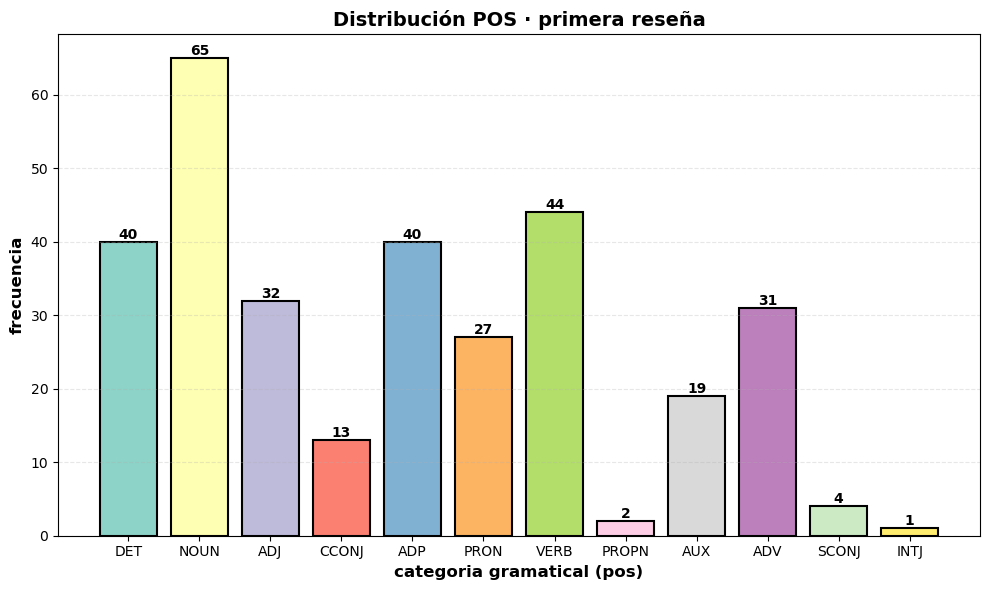

total de palabras sin puntuacion: 318


In [ ]:
# Distribución POS de la primera reseña 
doc_ejemplo = nlp(corpus['texto_limpio'].iloc[0])
graficar_distribucion_pos(doc_ejemplo, titulo='Distribución POS · primera reseña')
